# Wholesale Customers — Production-Grade Unsupervised Segmentation

Segment 440 wholesale accounts by **annual category spend** with a production pipeline:
winsorize → log1p → RobustScaler → multi-algorithm survey → k-sweep + stability → profiles.

`Channel` and `Region` are **held out** of clustering and used only as an external sanity check.

**Unsupervised:** no segment labels, no accuracy/confusion matrix.

In [1]:
from __future__ import annotations

import random
import sys
import warnings
from pathlib import Path

import matplotlib

matplotlib.use("module://matplotlib_inline.backend_inline")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.decomposition import PCA
from ucimlrepo import fetch_ucirepo

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from segmentation.metrics import internal_metrics, production_score
from segmentation.preprocess import prepare_matrix
from segmentation.selection import (
    labels_for_config,
    select_best_config,
    survey_algorithms,
    sweep_k,
    top_two_families,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")

import pycaret
import sklearn

print("Python:", sys.version.split()[0])
print("pycaret:", pycaret.__version__, "| sklearn:", sklearn.__version__)

Python: 3.13.13
pycaret: 4.0.0a8 | sklearn: 1.9.0


## 1. Data (UCI 292)

In [2]:
wholesale = fetch_ucirepo(id=292)
df = wholesale.data.original.copy()
print("Source: ucimlrepo id=292 original | shape:", df.shape)
print("Columns:", list(df.columns))
display(df.head())

deli = [c for c in df.columns if c.lower().startswith("delic")][0]
print("Delicatessen column:", repr(deli))
SPEND = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", deli]
HOLD = ["Channel", "Region"]

Source: ucimlrepo id=292 original | shape: (440, 8)
Columns: ['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


Delicatessen column: 'Delicassen'


## 2. EDA

Missing:
 Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


,mean,median,skew
Fresh,12000.297727,8504.0,2.561323
Milk,5796.265909,3627.0,4.053755
Grocery,7951.277273,4755.5,3.587429
Frozen,3071.931818,1526.0,5.907986
Detergents_Paper,2881.493182,816.5,3.631851
Delicassen,1524.870455,965.5,11.151586


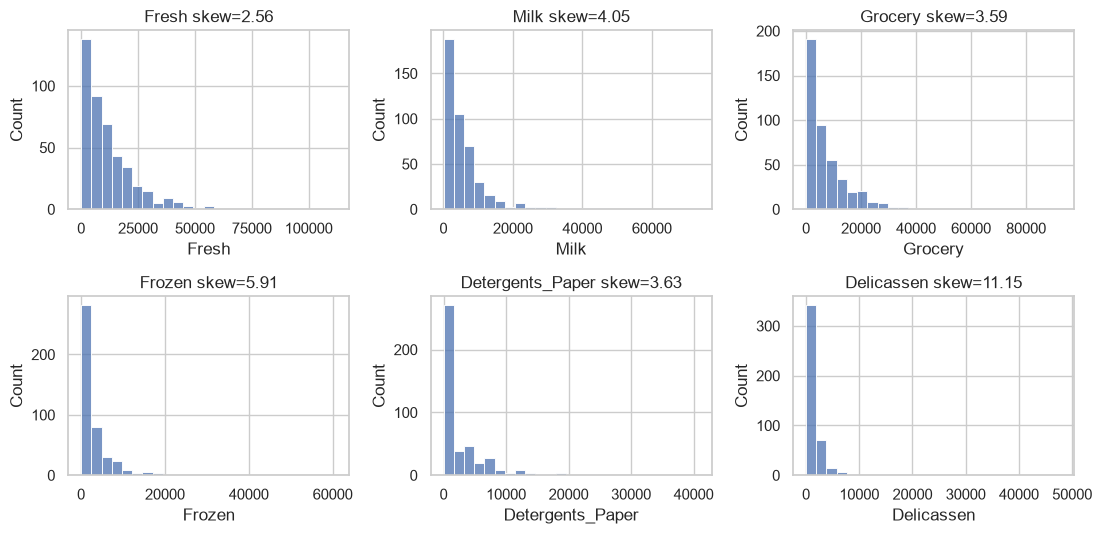

In [3]:
print("Missing:\n", df.isna().sum())
display(df[SPEND].describe())
cmp = pd.DataFrame(
    {
        "mean": df[SPEND].mean(),
        "median": df[SPEND].median(),
        "skew": df[SPEND].skew(),
    }
)
display(cmp)

fig, axes = plt.subplots(2, 3, figsize=(11, 5.5))
for ax, c in zip(axes.ravel(), SPEND):
    sns.histplot(df[c], bins=25, ax=ax)
    ax.set_title(f"{c} skew={df[c].skew():.2f}")
plt.tight_layout()
plt.show()

## 3. Production preprocessing

Category spends are heavily right-skewed. We **winsorize** (1–99%), **log1p** all six,
then **RobustScaler**. Channel/Region stay out of the matrix.

Meta: {'scaler': 'robust', 'log_cols': ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']}
Winsor bounds:
                    lower     upper
Fresh              28.46  56082.61
Milk              255.56  37610.06
Grocery           259.82  43435.74
Frozen             43.95  17964.82
Detergents_Paper    9.39  22571.61
Delicassen          7.39   8274.66


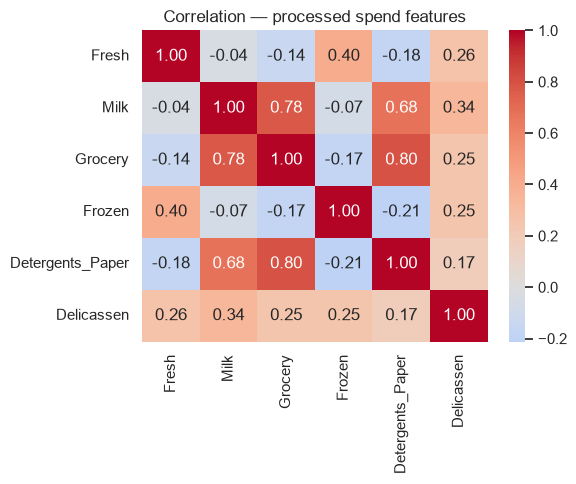

In [4]:
X, work, scaler, meta = prepare_matrix(
    df,
    SPEND,
    winsorize=True,
    log_cols=SPEND,
    scaler="robust",
)
print("Meta:", {k: meta[k] for k in ["scaler", "log_cols"]})
print("Winsor bounds:\n", meta["bounds"])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(pd.DataFrame(X, columns=SPEND).corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation — processed spend features")
plt.tight_layout()
plt.show()

## 4. Survey + deep k-sweep

,model,n_clusters,error,n_noise,noise_pct,largest_cluster_pct,min_cluster_pct,silhouette,davies_bouldin,calinski_harabasz,production_score
2,hclust,4,,0,0.0,52.500000,4.318182,0.227945,1.292284,110.309108,0.157872
1,minibatch_kmeans,4,,0,0.0,44.318182,12.954545,0.218146,1.616028,109.980827,0.122163
0,kmeans,4,,0,0.0,33.863636,14.318182,0.195445,1.428790,126.705677,0.114943
3,birch,4,,0,0.0,44.318182,8.181818,0.186447,1.567619,101.684080,0.094088
4,gmm,4,,0,0.0,41.818182,15.681818,0.155875,2.134014,85.221698,0.017710


Best 2 families: ['hclust', 'minibatch_kmeans']

=== Sweep hclust ===


,model,n_clusters,n_noise,noise_pct,largest_cluster_pct,min_cluster_pct,silhouette,davies_bouldin,calinski_harabasz,stability_ari,inertia,bic,aic,production_score
2,hclust,4,0,0.0,52.500000,4.318182,0.227945,1.292284,110.309108,0.531817,NaN,NaN,NaN,0.221690
1,hclust,3,0,0.0,52.500000,22.272727,0.217913,1.431848,123.060878,0.523089,NaN,NaN,NaN,0.199828
3,hclust,5,0,0.0,32.272727,4.318182,0.174754,1.623878,102.086435,0.505800,NaN,NaN,NaN,0.138602
4,hclust,6,0,0.0,32.272727,4.318182,0.177388,1.578785,94.758261,0.526540,NaN,NaN,NaN,0.117113
6,hclust,8,0,0.0,32.272727,4.318182,0.162401,1.467395,85.728769,0.534353,NaN,NaN,NaN,0.111704
5,hclust,7,0,0.0,32.272727,4.318182,0.162285,1.541691,89.899528,0.543533,NaN,NaN,NaN,0.106871
0,hclust,2,0,0.0,77.727273,22.272727,0.266266,1.670055,105.519376,0.122465,NaN,NaN,NaN,0.060372


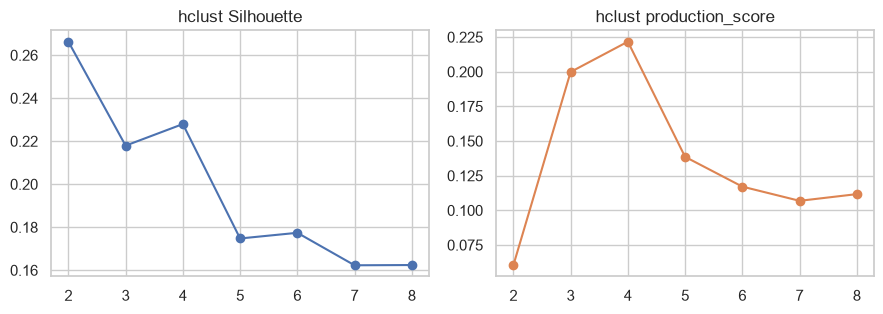


=== Sweep minibatch_kmeans ===


,model,n_clusters,n_noise,noise_pct,largest_cluster_pct,min_cluster_pct,silhouette,davies_bouldin,calinski_harabasz,stability_ari,inertia,bic,aic,production_score
0,minibatch_kmeans,2,0,0.0,54.318182,45.681818,0.251567,1.553243,149.156891,0.756492,1085.053700,NaN,NaN,0.222561
1,minibatch_kmeans,3,0,0.0,44.090909,22.045455,0.227726,1.520121,129.119395,0.394015,877.447193,NaN,NaN,0.187272
2,minibatch_kmeans,4,0,0.0,44.318182,12.954545,0.218146,1.616028,109.980827,0.500456,779.384540,NaN,NaN,0.182218
3,minibatch_kmeans,5,0,0.0,29.318182,9.772727,0.177581,1.713612,102.030611,0.345451,712.807907,NaN,NaN,0.115007
6,minibatch_kmeans,8,0,0.0,22.727273,4.772727,0.161698,1.547870,89.762430,0.477559,568.048132,NaN,NaN,0.097868
5,minibatch_kmeans,7,0,0.0,21.363636,11.363636,0.163880,1.519778,91.705605,0.410845,602.989906,NaN,NaN,0.094350
4,minibatch_kmeans,6,0,0.0,27.045455,10.000000,0.139837,1.702790,94.707905,0.478549,652.722162,NaN,NaN,0.063881


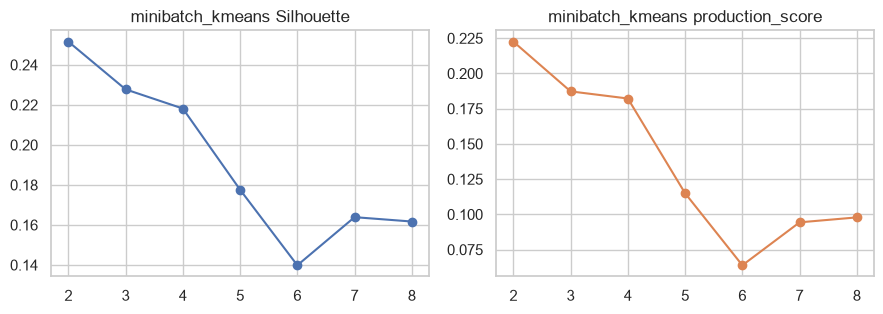

,model,n_clusters,n_noise,noise_pct,largest_cluster_pct,min_cluster_pct,silhouette,davies_bouldin,calinski_harabasz,stability_ari,inertia,bic,aic,production_score
7,minibatch_kmeans,2,0,0.0,54.318182,45.681818,0.251567,1.553243,149.156891,0.756492,1085.053700,NaN,NaN,0.222561
2,hclust,4,0,0.0,52.500000,4.318182,0.227945,1.292284,110.309108,0.531817,NaN,NaN,NaN,0.221690
1,hclust,3,0,0.0,52.500000,22.272727,0.217913,1.431848,123.060878,0.523089,NaN,NaN,NaN,0.199828
8,minibatch_kmeans,3,0,0.0,44.090909,22.045455,0.227726,1.520121,129.119395,0.394015,877.447193,NaN,NaN,0.187272
9,minibatch_kmeans,4,0,0.0,44.318182,12.954545,0.218146,1.616028,109.980827,0.500456,779.384540,NaN,NaN,0.182218
3,hclust,5,0,0.0,32.272727,4.318182,0.174754,1.623878,102.086435,0.505800,NaN,NaN,NaN,0.138602
4,hclust,6,0,0.0,32.272727,4.318182,0.177388,1.578785,94.758261,0.526540,NaN,NaN,NaN,0.117113
10,minibatch_kmeans,5,0,0.0,29.318182,9.772727,0.177581,1.713612,102.030611,0.345451,712.807907,NaN,NaN,0.115007
6,hclust,8,0,0.0,32.272727,4.318182,0.162401,1.467395,85.728769,0.534353,NaN,NaN,NaN,0.111704
5,hclust,7,0,0.0,32.272727,4.318182,0.162285,1.541691,89.899528,0.543533,NaN,NaN,NaN,0.106871


Configs:
  minibatch_kmeans k=2 prod=0.2226 sil=0.2516
  hclust k=4 prod=0.2217 sil=0.2279


In [5]:
survey = survey_algorithms(
    X,
    models=["kmeans", "minibatch_kmeans", "hclust", "birch", "gmm"],
    n_clusters=4,
    random_state=SEED,
)
display(survey)
best_two = top_two_families(survey)
print("Best 2 families:", best_two)

sweeps = {}
for fam in best_two:
    print(f"\n=== Sweep {fam} ===")
    sw = sweep_k(fam, X, ks=range(2, 9), random_state=SEED, compute_stability=True)
    sweeps[fam] = sw
    display(sw.sort_values("production_score", ascending=False))
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.3))
    axes[0].plot(sw["n_clusters"], sw["silhouette"], "o-")
    axes[0].set_title(f"{fam} Silhouette")
    axes[1].plot(sw["n_clusters"], sw["production_score"], "o-", color="C1")
    axes[1].set_title(f"{fam} production_score")
    plt.tight_layout()
    plt.show()

model_a, k_a, best_row, ranking = select_best_config(sweeps)
display(ranking.head(10))
configs = [(model_a, k_a, best_row)]
other = [m for m in best_two if m != model_a]
if other:
    sw_o = sweeps[other[0]].sort_values("production_score", ascending=False).iloc[0]
    configs.append((other[0], int(sw_o["n_clusters"]), sw_o))

print("Configs:")
for m, k, r in configs:
    print(f"  {m} k={k} prod={r['production_score']:.4f} sil={r['silhouette']:.4f}")

## 5. Final fits, PCA, profiles


### minibatch_kmeans k=2 {'n_clusters': 2, 'n_noise': 0, 'noise_pct': 0.0, 'largest_cluster_pct': 54.31818181818182, 'min_cluster_pct': 45.68181818181818, 'silhouette': 0.2515670489762707, 'davies_bouldin': 1.553242849384023, 'calinski_harabasz': 149.15689056383212, 'production_score': 0.2225613233333541}


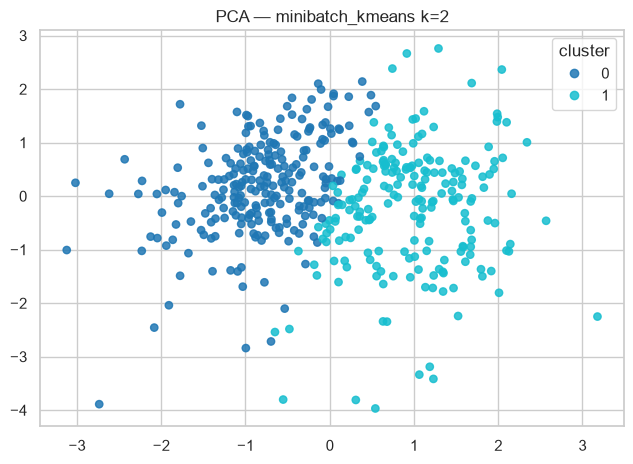

,cluster,n,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,mean_total,total_spend,pct_n,pct_spend
1,1,201,8640.527363,9879.064677,13708.965174,1908.582090,5696.243781,1898.218905,41731.601990,8388052,45.681818,57.375779
0,0,239,14825.878661,2362.615063,3109.037657,4050.313808,514.276151,1210.882845,26073.004184,6231448,54.318182,42.624221



### hclust k=4 {'n_clusters': 4, 'n_noise': 0, 'noise_pct': 0.0, 'largest_cluster_pct': 52.5, 'min_cluster_pct': 4.318181818181818, 'silhouette': 0.22794532821391333, 'davies_bouldin': 1.2922844331434247, 'calinski_harabasz': 110.30910806499465, 'production_score': 0.2216898720526171}


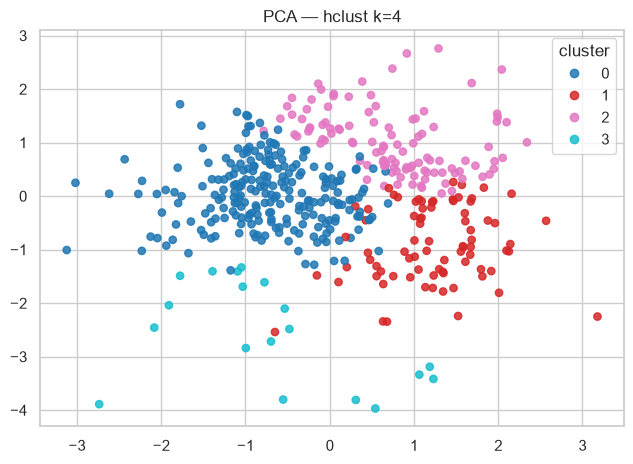

,cluster,n,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,mean_total,total_spend,pct_n,pct_spend
2,2,111,19677.396396,11435.846847,13925.864865,5115.792793,5218.657658,3234.666667,58608.225225,6505513,25.227273,44.498875
1,1,79,3346.240506,8525.177215,14867.493671,792.468354,6712.759494,1139.291139,35383.430380,2795291,17.954545,19.120291
0,0,231,12206.142857,2507.229437,3021.077922,3024.376623,574.372294,946.506494,22279.705628,5146612,52.500000,35.203748
3,3,19,629.894737,1490.473684,4231.052632,1187.421053,1347.263158,170.947368,9057.052632,172084,4.318182,1.177085


In [6]:
results = {}
for model_name, k, row in configs:
    labels = labels_for_config(model_name, X, k, random_state=SEED)
    m = internal_metrics(X, labels)
    m["production_score"] = production_score({**m, "stability_ari": row.get("stability_ari", np.nan)})
    print(f"\n### {model_name} k={k}", m)

    Z = PCA(2, random_state=SEED).fit_transform(X)
    fig, ax = plt.subplots(figsize=(6.5, 4.8))
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=labels, cmap="tab10", s=28, alpha=0.85)
    ax.set_title(f"PCA — {model_name} k={k}")
    ax.legend(*sc.legend_elements(), title="cluster")
    plt.tight_layout()
    plt.show()

    tmp = df.copy()
    tmp["cluster"] = labels
    tmp["row_spend"] = tmp[SPEND].sum(axis=1)
    g = tmp.groupby("cluster")
    prof = g[SPEND].mean()
    prof.insert(0, "n", g.size())
    prof["mean_total"] = g["row_spend"].mean()
    prof["total_spend"] = g["row_spend"].sum()
    prof = prof.reset_index()
    prof["pct_n"] = 100 * prof["n"] / prof["n"].sum()
    prof["pct_spend"] = 100 * prof["total_spend"] / prof["total_spend"].sum()
    prof = prof.sort_values("mean_total", ascending=False)
    display(prof)

    results[f"{model_name}_k{k}"] = {
        "model": model_name,
        "k": k,
        "labels": labels,
        "metrics": m,
        "profile": prof,
        "row": row,
    }

## 6. Comparison + Channel/Region sanity check

In [7]:
cmp = pd.DataFrame(
    [
        {
            "config": key,
            "model": r["model"],
            "k": r["k"],
            "silhouette": r["metrics"]["silhouette"],
            "davies_bouldin": r["metrics"]["davies_bouldin"],
            "calinski_harabasz": r["metrics"]["calinski_harabasz"],
            "largest_pct": r["metrics"]["largest_cluster_pct"],
            "stability_ari": r["row"].get("stability_ari", np.nan),
            "production_score": r["metrics"]["production_score"],
        }
        for key, r in results.items()
    ]
).sort_values("production_score", ascending=False)
display(cmp)
pref_key = cmp.iloc[0]["config"]
pref = results[pref_key]
print("PREFERRED:", pref_key)

sanity = df[HOLD].copy()
sanity["cluster"] = pref["labels"]
print("\nCluster × Channel (counts):")
display(pd.crosstab(sanity["cluster"], sanity["Channel"], margins=True))
print("Cluster × Channel (row %):")
display(pd.crosstab(sanity["cluster"], sanity["Channel"], normalize="index").mul(100).round(1))
print("Cluster × Region (row %):")
display(pd.crosstab(sanity["cluster"], sanity["Region"], normalize="index").mul(100).round(1))

for cl in sorted(set(pref["labels"])):
    sub = sanity.loc[sanity["cluster"] == cl]
    mode = sub["Channel"].value_counts(normalize=True)
    print(
        f"Cluster {cl}: n={len(sub)}, dominant Channel={mode.index[0]} "
        f"({100*mode.iloc[0]:.1f}%) — descriptive only"
    )

,config,model,k,silhouette,davies_bouldin,calinski_harabasz,largest_pct,stability_ari,production_score
0,minibatch_kmeans_k2,minibatch_kmeans,2,0.251567,1.553243,149.156891,54.318182,0.756492,0.222561
1,hclust_k4,hclust,4,0.227945,1.292284,110.309108,52.500000,0.531817,0.221690


PREFERRED: minibatch_kmeans_k2

Cluster × Channel (counts):


Channel,1,2,All
cluster,,,
0,232,7,239
1,66,135,201
All,298,142,440


Cluster × Channel (row %):


Channel,1,2
cluster,,
0,97.1,2.9
1,32.8,67.2


Cluster × Region (row %):


Region,1,2,3
cluster,,,
0,19.2,10.9,69.9
1,15.4,10.4,74.1


Cluster 0: n=239, dominant Channel=1 (97.1%) — descriptive only
Cluster 1: n=201, dominant Channel=2 (67.2%) — descriptive only


## 7. Manager brief

In [8]:
prof = pref["profile"]
print("MANAGER BRIEF — Wholesale Customers (production pipeline)")
print("=" * 64)
print(
    f"{pref['model']} k={pref['k']} | Sil={pref['metrics']['silhouette']:.3f} | "
    f"DB={pref['metrics']['davies_bouldin']:.3f} | CH={pref['metrics']['calinski_harabasz']:.1f} | "
    f"stab={pref['row'].get('stability_ari', float('nan')):.3f}"
)
for _, pr in prof.iterrows():
    top = max(SPEND, key=lambda c: pr[c])
    print(
        f"Segment {int(pr['cluster'])}: n={int(pr['n'])} ({pr['pct_n']:.1f}% accounts, "
        f"{pr['pct_spend']:.1f}% spend) | mean total≈{pr['mean_total']:.0f} | top category {top}≈{pr[top]:.0f}"
    )
    print("  → Align assortment, logistics SLA, and account coverage to category mix.")

print(
    "\nSanity: Channel/Region crosstabs above are descriptive only — not clustering accuracy."
)

MANAGER BRIEF — Wholesale Customers (production pipeline)
minibatch_kmeans k=2 | Sil=0.252 | DB=1.553 | CH=149.2 | stab=0.756
Segment 1: n=201 (45.7% accounts, 57.4% spend) | mean total≈41732 | top category Grocery≈13709
  → Align assortment, logistics SLA, and account coverage to category mix.
Segment 0: n=239 (54.3% accounts, 42.6% spend) | mean total≈26073 | top category Fresh≈14826
  → Align assortment, logistics SLA, and account coverage to category mix.

Sanity: Channel/Region crosstabs above are descriptive only — not clustering accuracy.
